**Pair trading** strategies expolit profit opportunities between two financial assets that tend to move together. **Cointegration** helps us grasp the long-term equilibrium relationships among multiple variables. In pairs trading, suitable pairs can exist even if the individual price series are non-stationary and exhibit stochastic trends. Such relationship can be analysed through the **spread** $z_t$ between two assets, which can be written as

$$
z_t = y_t − γx_t = µ + ϵ_t
$$
$$
y_t = µ + γx_t + ϵ_t
$$

Here, $µ$ represents the equilibrium value and $ϵ_t$ is the residual with zero mean. Cointegration is the core assumption underlying this relationship. If two time series are cointegrated, they tend to stay close to each other over the long term. This means that the spread $z_t$ is **stationary** and tends to **mean revert**. When the spread strays from the mean, arbitrage opportunities emerge and we can identify the optimal entry and exit points for such trades. First, we have to carry out statistical test to check whether the time series of the two assets are cointegrated. We apply this strategy to AUDUSD and NZDUSD currency pairs utilizing the most recent three years of price data.

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  2 of 2 completed


Cointegrated


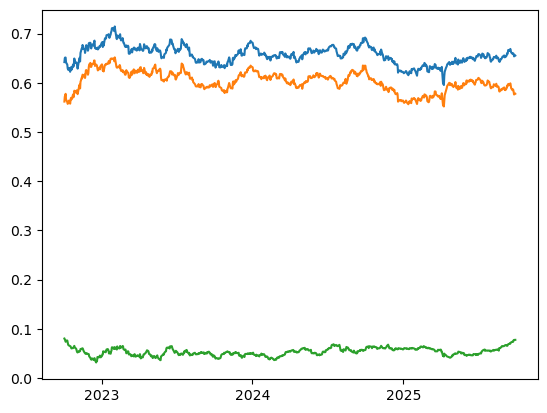

In [1]:
# Load and format trading data
import numpy as np
import pandas as pd
import yfinance as yf
x = 'AUDUSD=X'
y = 'NZDUSD=X'
start_date = '2022-10-01'
end_date = '2025-09-30'
df = yf.download([x, y], start=start_date, end=end_date, interval='1d')['Close'].rename(columns={x: 'x', y: 'y'})

# Carry out cointegration test
from statsmodels.tsa.stattools import coint
_, p, _ = coint(df["x"],df["y"])
is_cointegrated = p < 0.05
if is_cointegrated:
    print("Cointegrated")
else: print("Not cointegrated")

# Visualize the stationarity of the spread
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
plt.plot(df['x'])
plt.plot(df['y'])
plt.plot(df['x']-df['y']);
plt.gca().xaxis.set_major_locator(mdates.YearLocator())

The two time series are **cointegrated** and the spread is **stationary** across the three year horizon. Least Square regression could then be used to estimate the model parameters. In particluar, $ γ $ is the **hedge ratio** of relative size of positions in the two assets to make the portfolio market neutral. However, the assumption of constant parameters rarely holds in practice; in fact, they tend to vary over time across different horizons.

The **Kalman filter** could therefore be used as it continuously updates the parameters to adapt to dynamic market conditions, improving robustness over static models. It also filters out noise using covariance matrices to weigh prediction errors and measurement uncertainty. For example, $ Q $ is the process noise covariance matrix where a small value assumes a stable hedge ratio while a large value allows more flexibility. In turn, it effectively helps predict the dynamic spread between two correlated assets, improve trading signals and optimize entry and exit points.

**Z-scores** are computed to standardize the spread to measure how far it deviates from the rolling mean, signaling trading opportunities. Positions are entered or exited on the next trading day after signals are generated on the previous day close based on z-scores. The trading mechanism is as below:

- **Entry (long spread)** : If the z-score is below -0.75, the spread is too low, y is undervalued and x is overvalued. Enter trade of long spread on the next day (long 1 unit of y and short $ γ $ unit of x).
- **Entry (short spread)**: If the z-score is above 0.75, the spread is too high, y is overvalued and x is undervalued. Enter trade of short spread on the next day (short 1 unit of y and long $ γ $ unit of x).
- **Take Profit**: If the z-score revert to 0, close position on the next day.
- **Stop Loss**: In case of extreme market movement where |z-score| ≥ 3, close position on the next day and pause trading until z-score revert to the normal range of 0 ≤ |z-score| ≤ 0.75 to observe and engage again.

In [2]:
def kalman_pairs_trading(df, Q=1e-5, R=0.1, window=100, entry_z=0.75, tp_z=0, sl_z=2.5):
    
    # Initialize the Kalman filter
    prices_x = df['x'].values
    prices_y = df['y'].values
    n = len(prices_x)
    gamma = 0.0
    P = 1.0
    gammas = np.zeros(n)
    spreads = np.zeros(n)

    # Predict the spread and update the dynamic hedge ratio each day
    for t in range(n):
        gamma_pred = gamma
        P_pred = P + Q
        spreads[t] = prices_y[t] - gamma_pred * prices_x[t]
        H = prices_x[t]
        if abs(H) < 1e-8:  # Avoid division by zero
            gammas[t] = gamma
            continue
        resid = prices_y[t] - gamma_pred * H
        S = P_pred * H**2 + R
        K = P_pred * H / S
        gamma = gamma_pred + K * resid
        P = P_pred * (1 - K * H)
        gammas[t] = gamma
    
    # Compute the rolling z-score each day
    z_scores = np.zeros(n)
    for t in range(window, n):
        recent_spreads = spreads[t-window:t]
        mu = np.mean(recent_spreads)
        sigma = np.std(recent_spreads)
        if sigma < 1e-8:
            z_scores[t] = 0
            continue
        z_scores[t] = (spreads[t] - mu) / sigma
    
    # Generate the trading signal for the next day
    signals = np.zeros(n) # Signals to adjust position on next day open
    position = 0
    sl_triggered = False
    for t in range(window, n):
        z = z_scores[t]
        if sl_triggered and abs(z) <= entry_z: 
            sl_triggered = False  # Check if the z-score is back to normal range to resume trading
        if abs(z) >= sl_z: 
            sl_triggered = True
            signals[t] = 0  # Check if there is any stop-loss signal at today close, if yes, signal to exit position next day open
        else:
            if sl_triggered: 
                signals[t] = 0  # If stop loss is triggered, no new trades until the z-score returns to normal range
            else:
                if position == 0:
                    if z >= entry_z: 
                        signals[t] = -3  # The z-score too high, entry signal to short spread next day
                    elif z <= -entry_z: 
                        signals[t] = 3  # The z-score too low, entry signal to long spread next day
                    else: 
                        signals[t] = 0  # No entry signal, remain in no position
                elif position == 3:
                    if z >= -tp_z: 
                        signals[t] = 0  # Long spread position and the z-score elevates back higher, take profit signal to exit position next day
                    else: 
                        signals[t] = 3  # No take profit signal, maintain long spread position
                elif position == -3:
                    if z <= tp_z: 
                        signals[t] = 0  # Short spread position and the z-score decline back lower, take profit signal to exit position next day
                    else: 
                        signals[t] = -3  # No take profit signal, maintain short spread position
        if t < n - 1:  # Avoid out of bounds exceptions
            position = signals[t]  # Based on previous day's signal, update position for next day open
    
    # Update the position for the next day
    positions = np.zeros(n)
    positions[window + 1:] = signals[window:-1]  # Signal at the end of day 1 is the position at the open of day 2
    
    # Compute daily P&L
    pnl = np.zeros(n)
    for t in range(window + 1, n):
        delta_y = prices_y[t] - prices_y[t-1] if t > 0 else 0
        delta_x = prices_x[t] - prices_x[t-1] if t > 0 else 0
        pnl[t] = positions[t] * (delta_y - gammas[t] * delta_x)
    cum_pnl = np.cumsum(pnl)
    
    # Display trading statistics
    df['Spread Z-score'] = z_scores
    df['Spread Position'] = positions
    df['Hedge Ratio'] = gammas
    df['Cumulative P&L'] = cum_pnl
    return df

kalman_pairs_trading(df)

Ticker,x,y,Spread Z-score,Spread Position,Hedge Ratio,Cumulative P&L
Date,,,,,,
2022-10-03,0.642096,0.561861,0.000000,0.0,0.704233,0.000000
2022-10-04,0.650180,0.571961,0.000000,0.0,0.783564,0.000000
2022-10-05,0.651410,0.573730,0.000000,0.0,0.813905,0.000000
2022-10-06,0.651270,0.577601,0.000000,0.0,0.831263,0.000000
2022-10-07,0.641441,0.566069,0.000000,0.0,0.840870,0.000000
...,...,...,...,...,...,...
2025-09-23,0.660200,0.586880,-2.287901,0.0,0.913529,0.303864
2025-09-24,0.659780,0.585700,-2.303010,0.0,0.913356,0.303864
2025-09-25,0.658692,0.581660,-2.620516,0.0,0.913154,0.303864


The strategy displayed decent performance in terms of **cumulative P&L** as illustrated in the visualizations below (green line). The performance is particularly outstanding in periods of normal market volatility where the **z-score of spread** (blue line) is contained within range. **Entry and take profit signals** (pink line) effectively captured profit opportunities from mean reversions in the spread. The **stop loss signals** are effectively configured to protect the portoflio from huge loss from excessive one way market moves. By continuously adjusting the **dynamic hedge ratio** (grey line, final chart), the Kalman filter helped to minimize risk associated with the non-static price actions in either asset.

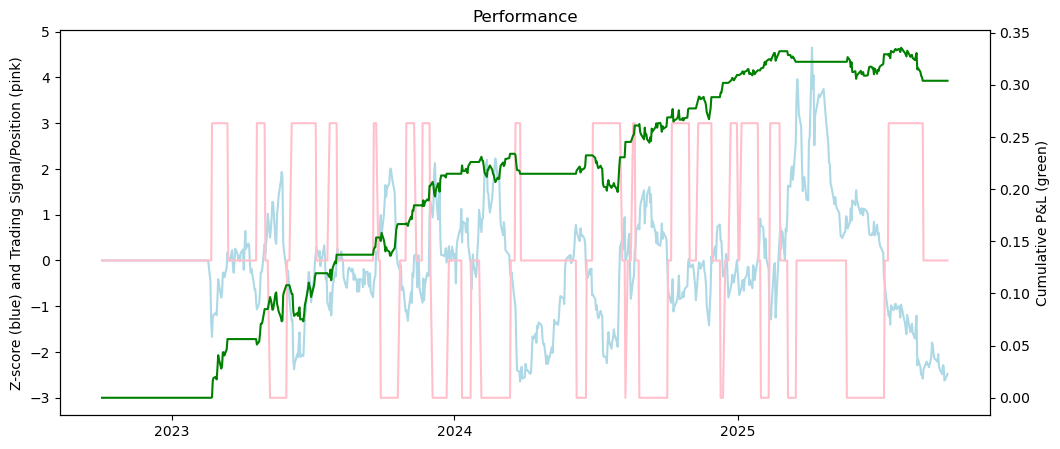

In [3]:
fig, (ax1) = plt.subplots(figsize=(12, 5))

ax1.plot(df.index, df['Spread Z-score'], color='lightblue', label='x')
ax1.plot(df.index, df['Spread Position'], color='pink', label='y')
ax1.set_ylabel('Z-score (blue) and Trading Signal/Position (pink)')
ax2 = ax1.twinx()
ax2.plot(df.index, df['Cumulative P&L'], color='green')
ax2.set_ylabel('Cumulative P&L (green)')
plt.title("Performance")
plt.gca().xaxis.set_major_locator(mdates.YearLocator())

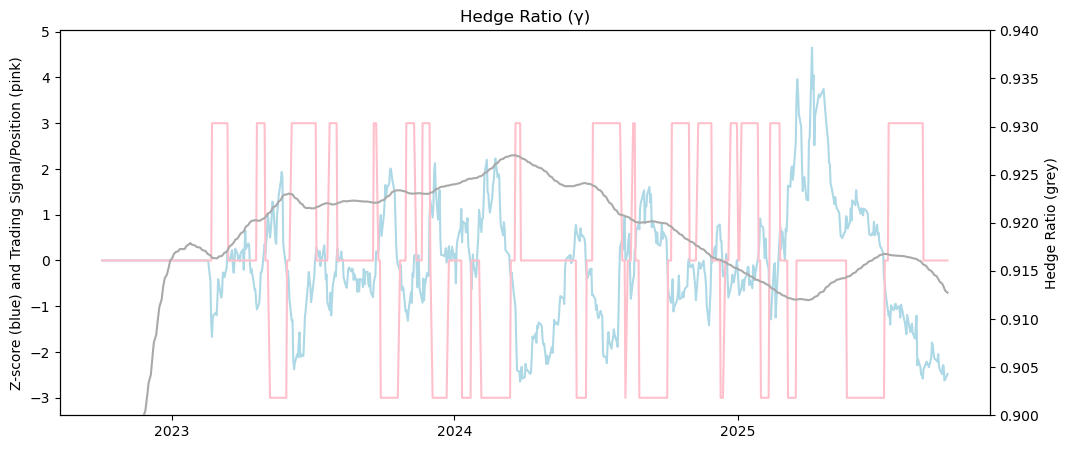

In [4]:
fig, (ax1) = plt.subplots(figsize=(12, 5))
ax1.plot(df.index, df['Spread Z-score'], color='lightblue')
ax1.plot(df.index, df['Spread Position'], color='pink')
ax1.set_ylabel('Z-score (blue) and Trading Signal/Position (pink)')
ax2 = ax1.twinx()
ax2.plot(df.index, df['Hedge Ratio'], color='darkgray')
ax2.set_ylabel('Hedge Ratio (grey)')
ax2.set_ylim(0.9, 0.94)
plt.title('Hedge Ratio (γ)')
plt.gca().xaxis.set_major_locator(mdates.YearLocator())